In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv('2015.csv')

display(df.head())
display(df.info())

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        158 non-null    object 
 1   Region                         158 non-null    object 
 2   Happiness Rank                 158 non-null    int64  
 3   Happiness Score                158 non-null    float64
 4   Standard Error                 158 non-null    float64
 5   Economy (GDP per Capita)       158 non-null    float64
 6   Family                         158 non-null    float64
 7   Health (Life Expectancy)       158 non-null    float64
 8   Freedom                        158 non-null    float64
 9   Trust (Government Corruption)  158 non-null    float64
 10  Generosity                     158 non-null    float64
 11  Dystopia Residual              158 non-null    float64
dtypes: float64(9), int64(1), object(2)
memory usage: 1

None

### Rename Columns & Check for NaNs

In [5]:
df = df.rename(columns={
    'Economy (GDP per Capita)': 'GDP_per_Capita',
    'Health (Life Expectancy)': 'Life_Expectancy',
    'Trust (Government Corruption)': 'Trust',
    'Happiness Rank': 'Rank',
    'Happiness Score': 'Score'
})

df = df.drop_duplicates()

missing_values = df.isnull().sum().sum()
print(f"Total missing values in dataset: {missing_values}")

Total missing values in dataset: 0


### Visualize Top 5 & Bottom 5 Countries

C:\Users\donga\AppData\Local\Temp\ipykernel_15840\1569040820.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=extremes, x='Score', y='Country', palette=['#2ecc71']*5 + ['#e74c3c']*5)


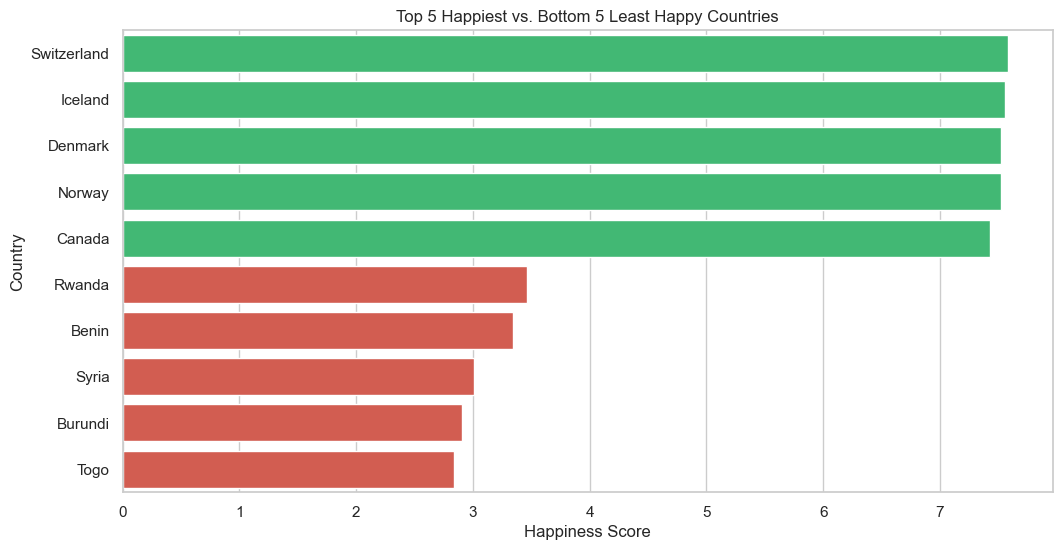

In [6]:
top_5 = df.head(5)
bottom_5 = df.tail(5)

extremes = pd.concat([top_5, bottom_5])

plt.figure(figsize=(12, 6))
sns.barplot(data=extremes, x='Score', y='Country', palette=['#2ecc71']*5 + ['#e74c3c']*5)
plt.title('Top 5 Happiest vs. Bottom 5 Least Happy Countries')
plt.xlabel('Happiness Score')
plt.ylabel('Country')
plt.show()

### Generate Correlation Heatmap

,Score,GDP_per_Capita,Family,Life_Expectancy,Freedom,Trust,Generosity
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,5.375734,0.846137,0.991046,0.630259,0.428615,0.143422,0.237296
std,1.145010,0.403121,0.272369,0.247078,0.150693,0.120034,0.126685
min,2.839000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.526000,0.545808,0.856823,0.439185,0.328330,0.061675,0.150553
50%,5.232500,0.910245,1.029510,0.696705,0.435515,0.107220,0.216130
75%,6.243750,1.158448,1.214405,0.811013,0.549092,0.180255,0.309883
max,7.587000,1.690420,1.402230,1.025250,0.669730,0.551910,0.795880


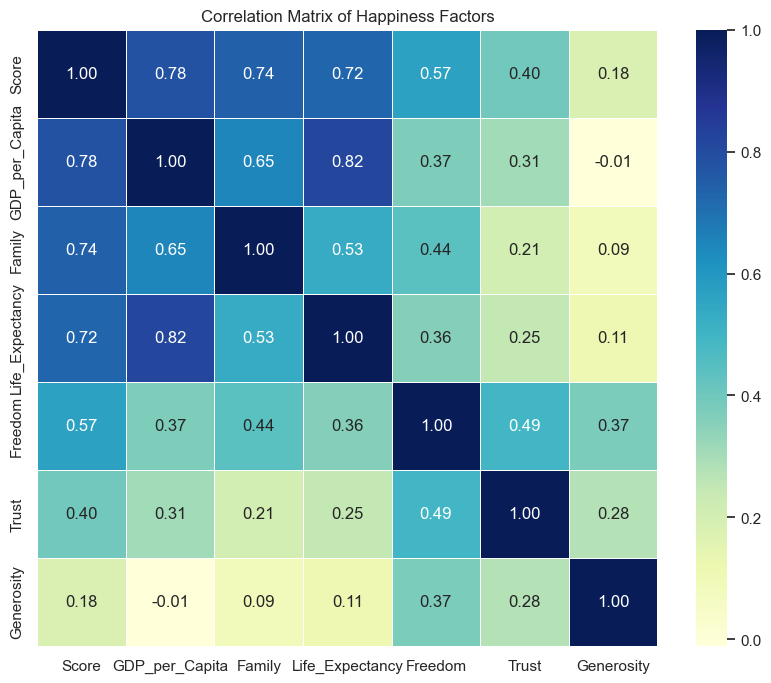

In [7]:
numeric_cols = ['Score', 'GDP_per_Capita', 'Family', 'Life_Expectancy', 'Freedom', 'Trust', 'Generosity']

display(df[numeric_cols].describe())

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Happiness Factors')
plt.show()

### Create Regression Plots (GDP & Life Expectancy)

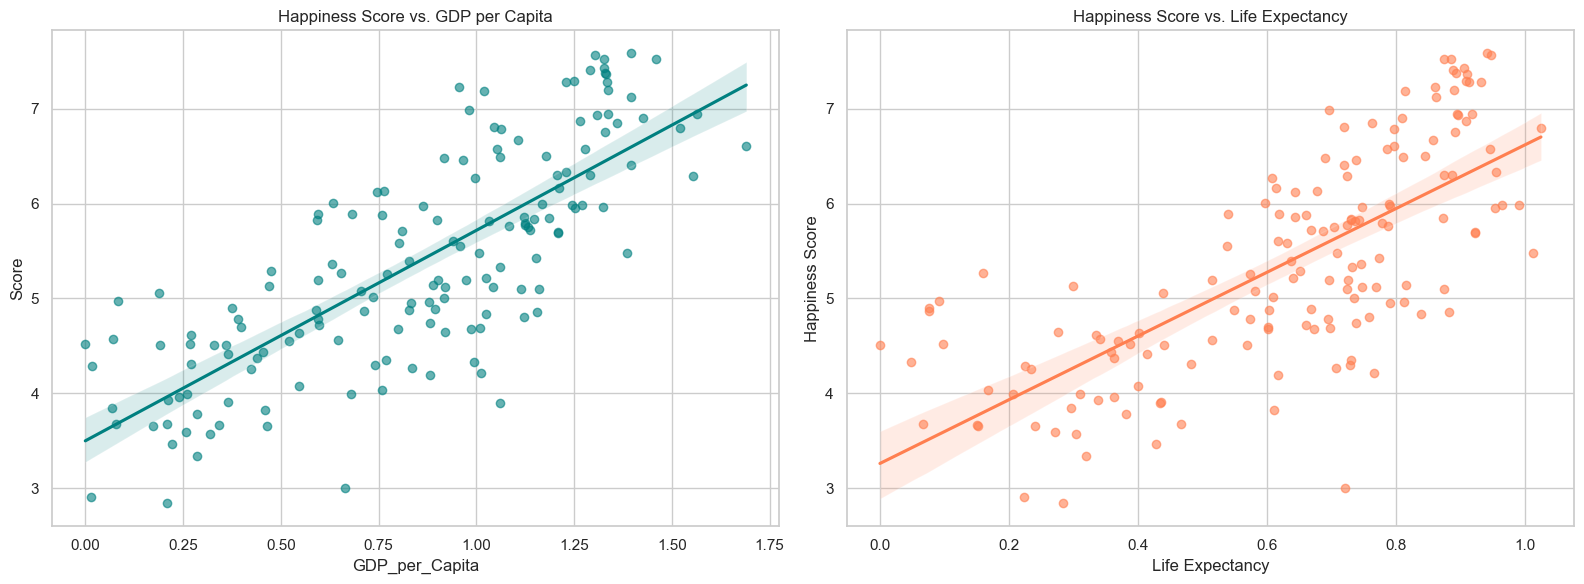

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(data=df, x='GDP_per_Capita', y='Score', ax=axes[0], scatter_kws={'alpha':0.6}, color='teal')
axes[0].set_title('Happiness Score vs. GDP per Capita')
plt.xlabel('GDP per Capita')
plt.ylabel('Happiness Score')

sns.regplot(data=df, x='Life_Expectancy', y='Score', ax=axes[1], scatter_kws={'alpha':0.6}, color='coral')
plt.title('Happiness Score vs. Life Expectancy')
plt.xlabel('Life Expectancy')
plt.ylabel('Happiness Score')

plt.tight_layout()
plt.show()

### Regional Average Score Visualization

C:\Users\donga\AppData\Local\Temp\ipykernel_15840\4001833675.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=regional_score, x='Score', y='Region', palette='viridis')


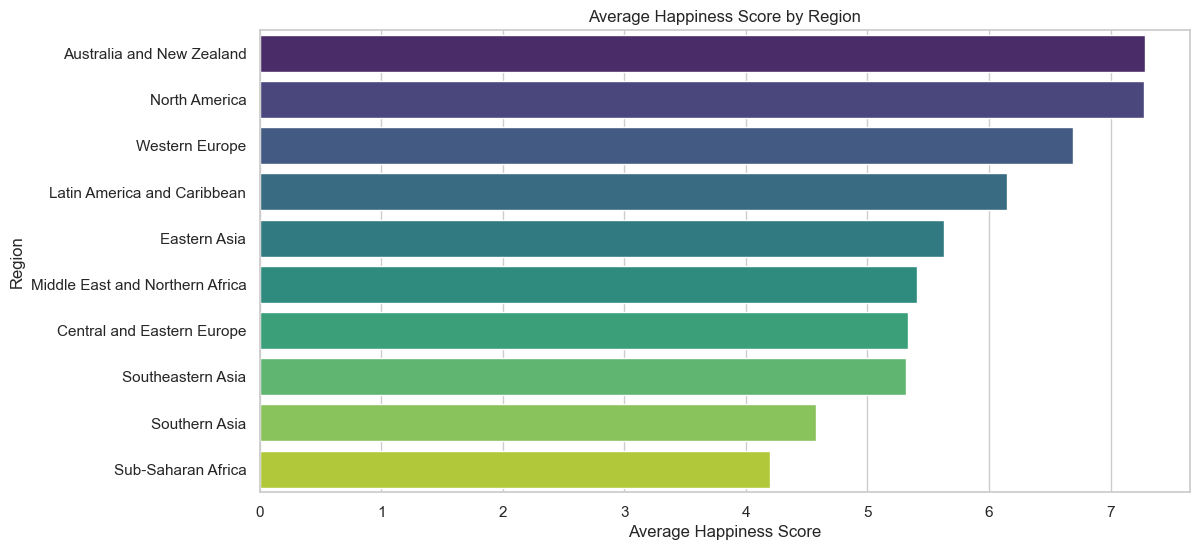

In [10]:
regional_score = df.groupby('Region')['Score'].mean().reset_index()
regional_score = regional_score.sort_values(by='Score', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=regional_score, x='Score', y='Region', palette='viridis')
plt.title('Average Happiness Score by Region')
plt.xlabel('Average Happiness Score')
plt.ylabel('Region')
plt.show()

### The Impact of Freedom on Happiness

In [14]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Freedom', y='Happiness Score', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Freedom to Make Life Choices vs. Happiness Score')
plt.xlabel('Freedom Score')
plt.ylabel('Happiness Score')
plt.show()

KeyError: 'Happiness Score'

<Figure size 1000x600 with 0 Axes>

### Factor Composition of Happiness Score for Top 5 Countries

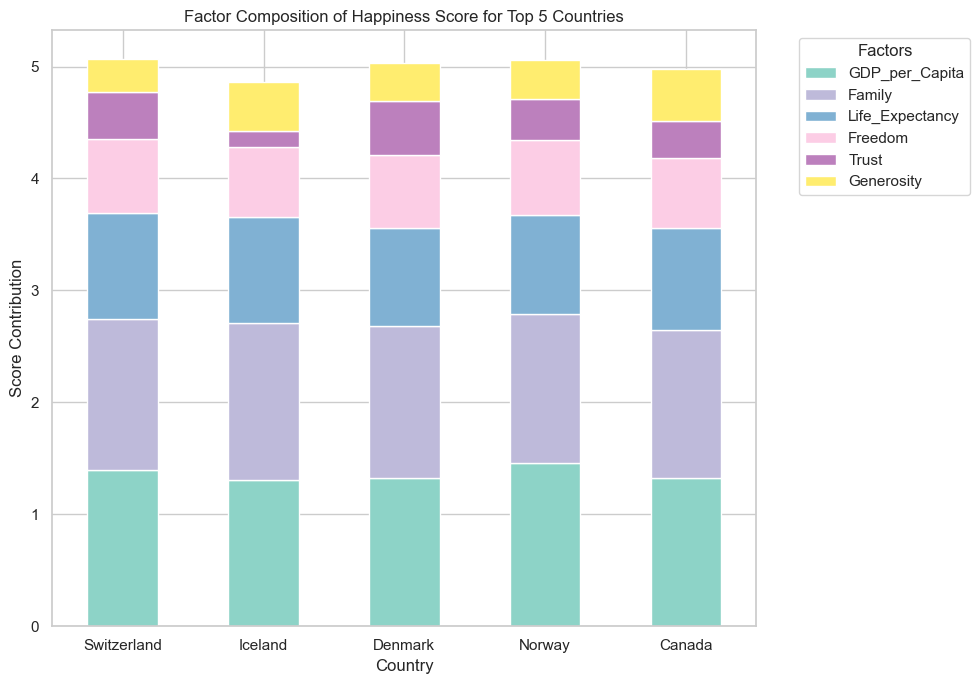

In [13]:
top_5_factors = top_5.set_index('Country')[['GDP_per_Capita', 'Family', 'Life_Expectancy', 'Freedom', 'Trust', 'Generosity']]

top_5_factors.plot(kind='bar', stacked=True, figsize=(10, 7), colormap='Set3')
plt.title('Factor Composition of Happiness Score for Top 5 Countries')
plt.xlabel('Country')
plt.ylabel('Score Contribution')
plt.legend(title='Factors', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Final Insight

## Project Overview
This notebook performs World Happiness data analysis using Python. The dataset is cleaned and processed using Pandas to prepare it for analysis. Different statistical operations are performed to understand the factors that affect happiness scores across different countries.

## Data Analysis
The code analyzes important information such as:
- Happiness score of different countries.
- Factors like GDP, social support, life expectancy, freedom, generosity, and corruption.
- Comparison of happiness scores between countries.
- Relationships between happiness score and other features in the dataset.

## Data Visualization
Different charts are used to make the analysis easier to understand:
- **Bar Charts** compare happiness scores and other factors across different countries.
- **Pie Charts** show the percentage distribution of selected categories in the dataset.
- **Line Charts** display trends and changes in numerical values.
- **Scatter Plots** show the relationship between happiness score and factors such as GDP or life expectancy.
- **Heatmap** displays the correlation between numerical features, helping identify which factors have the strongest impact on happiness.

## Conclusion
This notebook combines data analysis and visualization to better understand the World Happiness dataset. The charts help compare countries, identify important factors, and discover patterns that explain differences in happiness levels around the world.